# AI-Powered Financial Fraud Detection and Risk Analysis System Using Machine Learning

# Notebook 3: Feature Engineering & Class Imbalance Handling

## Objective

The objective of this notebook is to engineer additional predictive features and handle the severe class imbalance using multiple resampling techniques. The resulting balanced datasets will be used for training anomaly detection and machine learning models.

---

In [19]:
# ==========================================================
# IMPORT REQUIRED LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN
)

from imblearn.under_sampling import RandomUnderSampler

pd.set_option("display.max_columns", None)

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


In [20]:
df = pd.read_csv("../data/processed/cleaned_transactions.csv")

print(df.shape)
df.head()

(283726, 34)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Scaled_Amount,Hour,Time_Period
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244200,0,Night
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342584,0,Night
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.158900,0,Night
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.139886,0,Night
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073813,0,Night


## Feature Engineering

In [21]:
df["Log_Amount"] = np.log1p(df["Amount"])

In [22]:
threshold = df["Amount"].quantile(0.95)

df["High_Amount_Flag"] = (df["Amount"] > threshold).astype(int)

In [23]:
def amount_risk(amount):

    if amount < 100:
        return "Low"

    elif amount < 1000:
        return "Medium"

    else:
        return "High"

df["Amount_Risk"] = df["Amount"].apply(amount_risk)

In [24]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Scaled_Amount,Hour,Time_Period,Log_Amount,High_Amount_Flag,Amount_Risk
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244200,0,Night,5.014760,0,Medium
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342584,0,Night,1.305626,0,Low
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.158900,0,Night,5.939276,1,Medium
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.139886,0,Night,4.824306,0,Medium
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073813,0,Night,4.262539,0,Low


In [25]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [26]:
fig = px.bar(
    x=df["Class"].value_counts().index,
    y=df["Class"].value_counts().values,
    labels={
        "x":"Class",
        "y":"Count"
    },
    title="Class Distribution Before Balancing"
)

fig.show()

In [27]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [28]:
# Convert categorical columns to numeric

df = pd.get_dummies(
    df,
    columns=["Time_Period", "Amount_Risk"],
    drop_first=True
)

In [29]:
ros = RandomOverSampler(random_state=42)

X_ros, y_ros = ros.fit_resample(X, y)

print(y_ros.value_counts())

Class
0    283253
1    283253
Name: count, dtype: int64


In [30]:
rus = RandomUnderSampler(random_state=42)

X_rus, y_rus = rus.fit_resample(X, y)

print(y_rus.value_counts())

Class
0    473
1    473
Name: count, dtype: int64


In [31]:
smote = SMOTE(random_state=42)

X = df.drop("Class", axis=1)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print(y_smote.value_counts())

print(y_smote.value_counts())

Class
0    283253
1    283253
Name: count, dtype: int64
Class
0    283253
1    283253
Name: count, dtype: int64


In [32]:
adasyn = ADASYN(random_state=42)

X_ada, y_ada = adasyn.fit_resample(X, y)

print(y_ada.value_counts())

Class
1    283402
0    283253
Name: count, dtype: int64


In [33]:
comparison = pd.DataFrame({

    "Original":[y.value_counts()[0],y.value_counts()[1]],

    "Oversampling":[y_ros.value_counts()[0],y_ros.value_counts()[1]],

    "Undersampling":[y_rus.value_counts()[0],y_rus.value_counts()[1]],

    "SMOTE":[y_smote.value_counts()[0],y_smote.value_counts()[1]],

    "ADASYN":[y_ada.value_counts()[0],y_ada.value_counts()[1]]

},

index=["Normal","Fraud"])

comparison

,Original,Oversampling,Undersampling,SMOTE,ADASYN
Normal,283253,283253,473,283253,283253
Fraud,473,283253,473,283253,283402


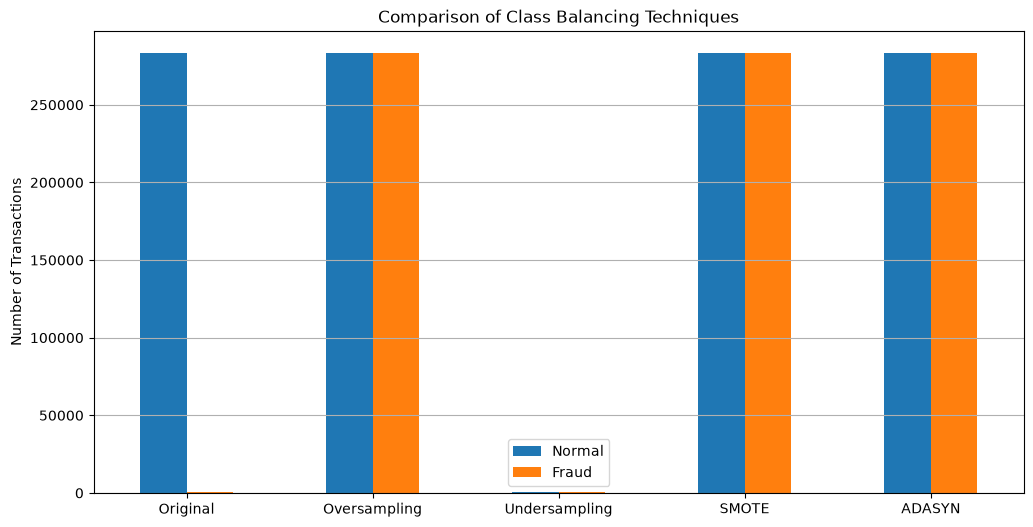

In [34]:
comparison.T.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Class Balancing Techniques")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

In [35]:
balanced_df = pd.concat(
    [
        pd.DataFrame(X_smote, columns=X.columns),
        pd.Series(y_smote, name="Class")
    ],
    axis=1
)

balanced_df.to_csv(
    "../data/processed/smote_balanced_dataset.csv",
    index=False
)

print("SMOTE Balanced Dataset Saved Successfully")

SMOTE Balanced Dataset Saved Successfully


# Business Insights

### Key Findings

- Severe class imbalance exists in the original dataset.
- Random Oversampling duplicates minority samples.
- Random Undersampling removes many legitimate transactions.
- SMOTE creates synthetic fraud samples while preserving information.
- ADASYN generates synthetic samples with greater focus on difficult cases.

SMOTE offers a strong balance between data preservation and model performance, making it a suitable choice for supervised classification experiments.

# Conclusion

This notebook successfully engineered additional features and evaluated multiple techniques for handling class imbalance.

The balanced datasets are now ready for machine learning model development.

In the next notebook, we will implement the **Isolation Forest** algorithm to perform anomaly detection on the original dataset and compare its performance with supervised approaches.

In [36]:
print("="*60)
print("Notebook 3 Completed Successfully")
print("="*60)

Notebook 3 Completed Successfully
